In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')

from utils import *
from matplotlib.collections import PolyCollection

circle = Hypersphere(1)
manifold_type = 'S1'


# Set Parameters

In [19]:
n_samples = 1000
sigma2 = .1

# prior param
num_modes = 4
tau2 = 0.05
G_params = {'tau2': tau2, 'num_modes': num_modes} 

# for empirical density estimation
M = 4
rho = 1e-1

# for oracle approximation
num_oracle_samples = 10000
oracle_bandwidth = 0.001


In [20]:
Theta = multimodal_sampler(n_samples,manifold_type, G_params)
X = circle.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

delta = denoiser('S1', X, M, rho, sigma2, X)
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, lambda n: multimodal_sampler(n, manifold_type, G_params) )
oracle_delta_B = oracle_bayes(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, lambda n: multimodal_sampler(n, manifold_type, G_params) )

loss_N = (sphere.metric.squared_dist(X, Theta)).mean()
loss_T = (sphere.metric.squared_dist(delta, Theta)).mean()
loss_oracle_T = (sphere.metric.squared_dist(oracle_delta_T, Theta)).mean()
loss_oracle_B = (sphere.metric.squared_dist(oracle_delta_B, Theta)).mean()

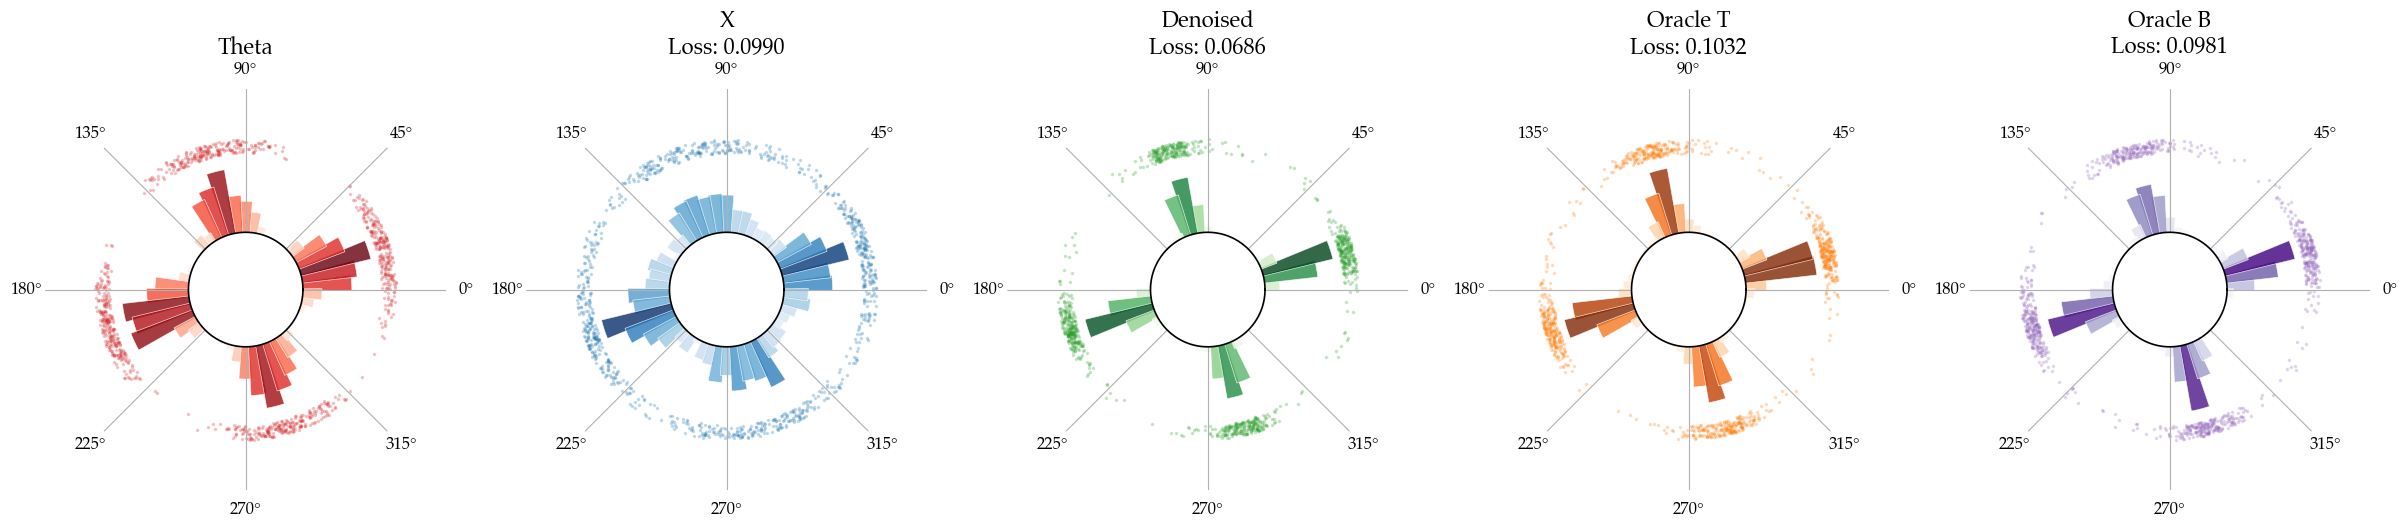

In [21]:
fig, axs = plt.subplots(1, 5, figsize=(30, 10), subplot_kw={'polar': True}, sharey=True)

size = 2.5; jitter_std = 5e-2; alpha = .2

S1_scatter(Theta, axs[0], 'C3', alpha, size,jitter_std)
S1_scatter(X, axs[1], 'C0', alpha, size, jitter_std)
S1_scatter(delta, axs[2], 'C2', alpha, size, jitter_std )
S1_scatter(oracle_delta_T, axs[3], 'C1', alpha, size, jitter_std)
S1_scatter(oracle_delta_B, axs[4], 'C4', alpha, size, jitter_std)

nbins = 50
S1_histogram(Theta, nbins, axs[0], 'Reds', .5)
S1_histogram(X, nbins, axs[1], 'Blues',  .5)
S1_histogram(delta, nbins, axs[2], 'Greens',  .5)
S1_histogram(oracle_delta_T, nbins, axs[3], 'Oranges', .5)
S1_histogram(oracle_delta_B, nbins, axs[4], 'Purples', .5)

for ax, title, loss in zip(axs, ['Theta', 'X', 'Denoised', 'Oracle T', 'Oracle B'], [None, loss_N, loss_T, loss_oracle_T, loss_oracle_B]):
    if title != 'Theta': ax.set_title(f'{title}\nLoss: {loss:.4f}', fontsize=16)
    else: ax.set_title(title, fontsize=16)
plt.show()


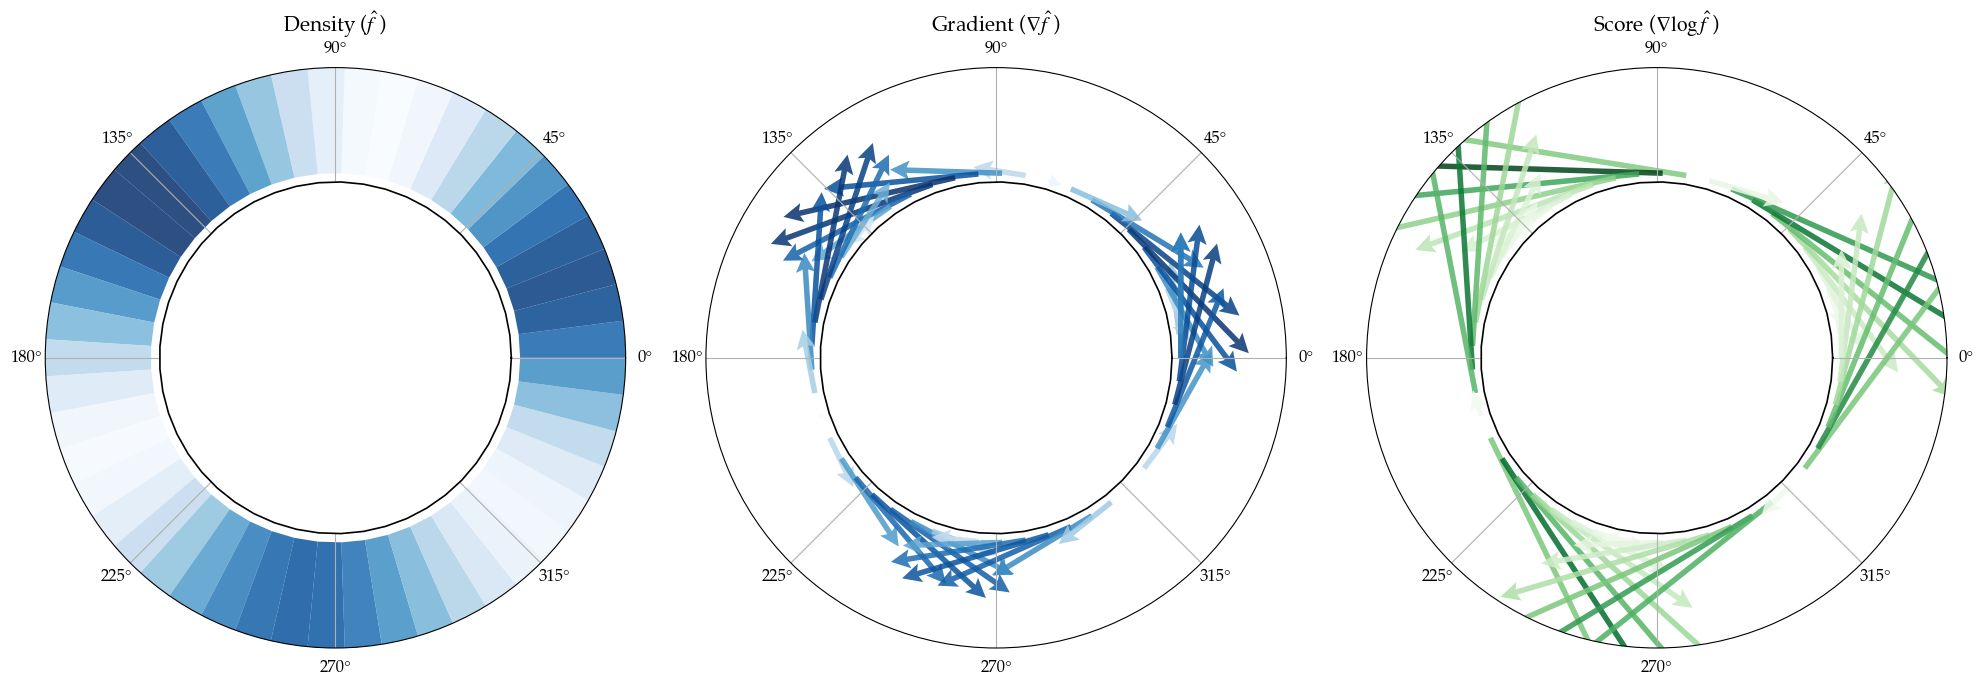

In [12]:
if True:
    f_scale = 0.3
    bottom = 0.105
    top = .5
    disk_r = 0.1

    fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
    grid_I = np.linspace(0, 2*np.pi, 50)
    grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    _, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)
    # ---------- DENSITY ---------------------------------------------------------------------------
    hat_pos_f = np.maximum(hat_f, 0)
    normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
    verts = [[
            (grid_I[i], bottom),
            # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
            (grid_I[i],top), (grid_I[i+1], bottom + top),
            (grid_I[i+1], bottom)
        ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
    poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                        alpha=0.85, edgecolors='none')
    axs[0].add_collection(poly)
    axs[0].set_title('Density ($\hat f$)', fontsize=15)
    # ---------- GRADIENT ---------------------------------------------------------------------------
    axs[1].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_grad_f[:, 0],          
        hat_grad_f[:, 1],          
        np.linalg.norm(hat_grad_f, axis=1),                 
        scale=4,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Blues',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)
    # ---------- SCORE ---------------------------------------------------------------------------
    hat_score = hat_grad_f /  np.maximum(hat_f.reshape(-1, 1), rho)
    axs[2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_score[:, 0],          
        hat_score[:, 1],          
        np.linalg.norm(hat_score, axis=1),                 
        scale=7,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)
    # -------------------------------------------------------------------------------------
    for ax in axs: 
        ax.set_ylim(0, bottom + f_scale*.2)  
        ax.set_yticks([])
        ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
    plt.tight_layout()
    plt.show()

<!-- # Visualisation -->

-----